# This notebook provides examples on how to use the parthenon-interface python module. 

## Initializing a simulation

First, load the module: We simply load in the interface.py file directly, since we are in the same folder. If you want to use it from somewhere else, pip-install the module instead. 

In [1]:
from interface import Simulation

Next, we define our first simulation object. We do this by giving the absolute or relative path to our simulation output folder to the initializer of the Simulation class: 

As an example, we use an input file adapted from https://github.com/parthenon-hpc-lab/athenapk/blob/main/inputs/turbulence.in. 

In [2]:
s = Simulation("example_folder")

## Getting an overview

Simply typing the objects name gives you an overview of your simulation: 

In [ ]:
s 

Problem ID,turbulence
Comment,Turbulence with parabolic forcing profile (using few driving modes)
Directory,example_folder
Elapsed time,0.7527


On top, you see some basic information, such as the Problem ID, any comment, the directory path and the total elapsed time of your simulation. 

The next section automatically plots the history file. Each quantity in the History file is plotted as a function of time. Use the buttons on top to select which quantity you want to see. 

The next (collapsed) sections show you an automatic overview of any spectra and openpmd slices (if your simulation outputted them).

The next sections show you a rendered overview of your input file, as well as a list of all output files that were found. 

## Accessing the history output 

The *s.history* property returns the history data as a *pandas* dataframe:

In [4]:
hst = s.history
hst 

,time,dt,cycle,nbtotal,mass,1-mom,2-mom,3-mom,KE,tot-E,ME,relDivB,Ms,Ma,plasma_beta
0,0.000000,0.009374,0,64,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,10000.0,0.000050,0.000000,0.000000,0.00000,20000.0
1,0.055014,0.008956,6,64,1.0,-5.574540e-20,-2.949580e-18,-6.902260e-19,0.000289,10000.0,0.000050,0.000085,0.022251,2.22508,19999.9
2,0.107813,0.008565,12,64,1.0,-1.026710e-18,-3.364840e-19,3.443190e-18,0.001016,10000.0,0.000050,0.000234,0.041809,4.18014,19998.0
3,0.150040,0.008277,17,64,1.0,-7.094110e-18,1.956010e-18,7.835050e-18,0.001846,10000.0,0.000050,0.000379,0.056222,5.61882,19992.2
4,0.207172,0.008033,24,64,1.0,-9.200050e-18,-1.538080e-17,-6.257460e-19,0.003302,10000.0,0.000050,0.000589,0.075069,7.49514,19972.1
5,0.254846,0.007827,30,64,1.0,-1.931660e-17,5.001730e-18,9.395710e-19,0.004882,10000.0,0.000050,0.000789,0.091069,9.08183,19940.6
6,0.301369,0.007664,36,64,1.0,-8.331420e-18,6.722050e-18,2.301810e-17,0.006796,10000.0,0.000051,0.000992,0.107480,10.70080,19893.7
7,0.354298,0.007416,43,64,1.0,4.147920e-18,3.649860e-18,-2.199340e-17,0.009288,10000.0,0.000051,0.001247,0.125726,12.48480,19823.7
8,0.405532,0.007198,50,64,1.0,1.962280e-17,-3.091860e-17,3.247100e-18,0.011941,10000.0,0.000052,0.001532,0.142652,14.11470,19743.5
9,0.455355,0.007014,57,64,1.0,-4.074230e-19,1.774920e-17,4.031790e-17,0.014802,10000.0,0.000053,0.001850,0.158794,15.64940,19665.0


As with any *pandas* dataframe, individual collumns are selected as follows: 

In [9]:
hst["ME"]

0     0.000050
1     0.000050
2     0.000050
3     0.000050
4     0.000050
5     0.000050
6     0.000051
7     0.000051
8     0.000052
9     0.000053
10    0.000055
11    0.000057
12    0.000059
13    0.000061
14    0.000065
15    0.000069
Name: ME, dtype: float64

By default, this returns a *pandas.series* object, which can be passed directly into matplotlib for plotting or converted into a numpy array. 

## Accessing other output types

A list of all availabe outputs is accessed as follows: 

In [12]:
s.outputs 

id,type,frames,time range
prim,hdf5,9,0 – 0.7
restart,?,0,—
sl.x1.0.5,openpmd,16,0 – 0.75
spc_v,spectrum,16,0 – 0.7
spc_B,spectrum,16,0 – 0.7
spc_rho,spectrum,16,0 – 0.7


To select an output type, simply do: 

In [13]:
s.outputs["prim"]

OutputSeries(hdf5 [prim], 9 frames)

This returns an *OutputSeries* object. There are two ways to access different snapshots. Either via the index: 

In [15]:
s.outputs["sl.x1.0.5"][0]

OutputFrame(idx=0, t=0, file=parthenon.sl.x1.0.5.00000.bp)

Or by passing the simulation time in code units. In this case, the interface will load the snapshot that is closest to the passed time :

In [20]:
s.outputs["sl.x1.0.5"].at(t = 0)

OutputFrame(idx=0, t=0, file=parthenon.sl.x1.0.5.00000.bp)

This returns an *OutputFrame* object. The properties of this object depend on the output type. Generically, each output type has the attribute *.data* which returns the raw data in whatever format is fitting. 

In [21]:
s.outputs["sl.x1.0.5"].at(t = 0).data 

{'fields': {'density': array([[1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         ...,
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.]], shape=(32, 32)),
  'magnetic_field_1': array([[0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         ...,
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01]], shape=(32, 32)),
  'magnetic_field_2': array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]], shape=(32, 32)),
  'magnetic_field_3': array([[0., 0., 0., ..., 0., 

In the following, we give an overview on how to access different output types: 

### phdf files

In [23]:
s.outputs["prim"].at(t = 0)

OutputFrame(idx=0, t=0, file=parthenon.prim.00000.phdf)

This returns an overview of all available fields. Again, *.data* returns the raw data, in this case a *yt* *dataset* object.  

In [ ]:
ds = s.outputs["prim"].at(t = 0).data

type(ds)

yt.frontends.parthenon.data_structures.ParthenonDataset

For details on how to work with these, check the yt documentation: https://yt-project.org/doc/quickstart/2%29_Data_Inspection.html

Select a field as follows:

YTFieldFrame(field=('parthenon', 'prim_density'), t=0.7)
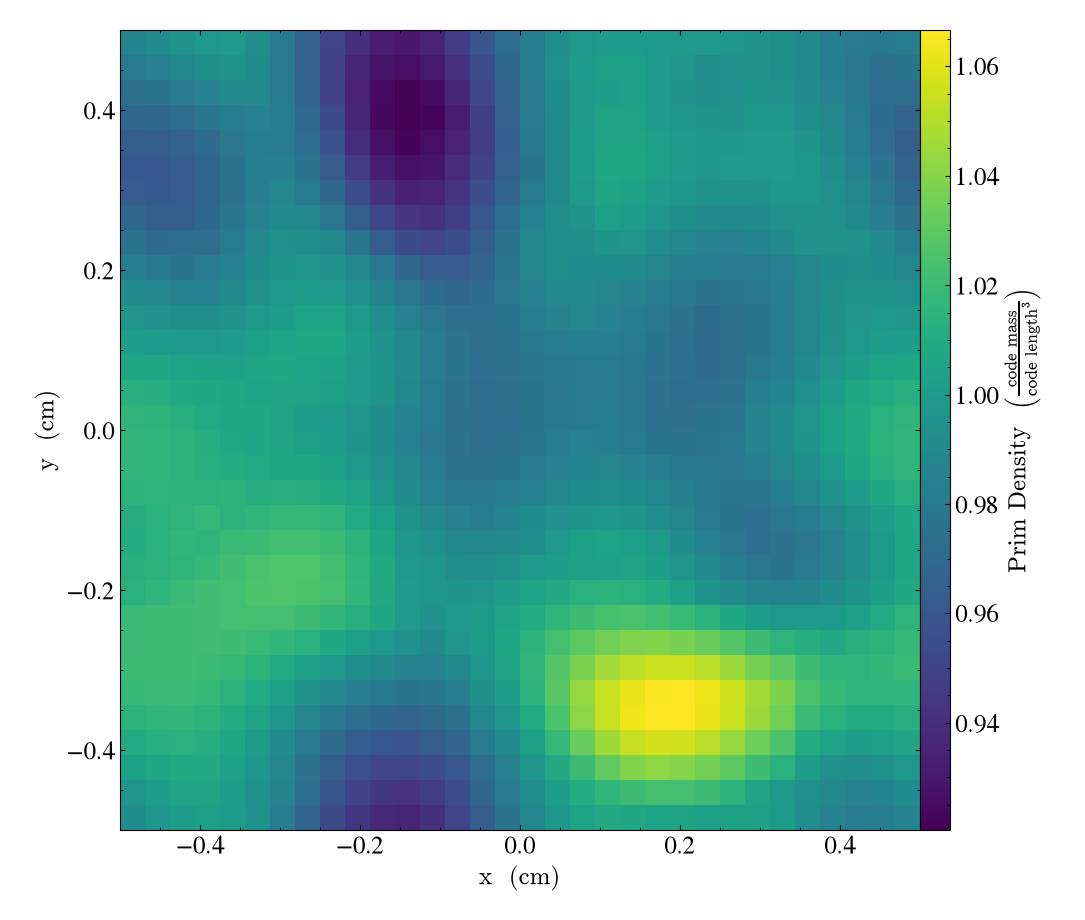

In [28]:
s.outputs["prim"].at(t = 1)[("parthenon", "prim_density")]

This uses yt to plot a slice by default. To access the full datacube: 

In [29]:
s.outputs["prim"].at(t = 1)[("parthenon", "prim_density")].data 

array([[[0.96987963, 0.96229506, 0.96046752, ..., 1.00290823,
         0.98522711, 0.98185289],
        [0.97103035, 0.96408391, 0.9612537 , ..., 1.00433731,
         0.98754454, 0.98460102],
        [0.97175545, 0.96480775, 0.96182108, ..., 1.00424588,
         0.98694718, 0.98489714],
        ...,
        [0.96535438, 0.9622193 , 0.96361065, ..., 0.98953819,
         0.97984779, 0.97072583],
        [0.96503383, 0.96118951, 0.95965135, ..., 0.99278343,
         0.98001218, 0.97283107],
        [0.96654916, 0.96164089, 0.95956844, ..., 0.99753284,
         0.98113781, 0.97800571]],

       [[0.9699741 , 0.96609229, 0.96430504, ..., 1.00303566,
         0.9864713 , 0.98322874],
        [0.97256339, 0.96789938, 0.96569872, ..., 1.00480199,
         0.98971218, 0.98318994],
        [0.97378486, 0.96960342, 0.96721131, ..., 1.00542665,
         0.98920321, 0.98348731],
        ...,
        [0.96608108, 0.96303165, 0.96105832, ..., 0.99200368,
         0.9815408 , 0.97116691],
        [0.9

### Openpmd slices

In [33]:
s.outputs["sl.x1.0.5"].at(t = 0).data 

{'fields': {'density': array([[1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         ...,
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.]], shape=(32, 32)),
  'magnetic_field_1': array([[0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         ...,
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01],
         [0.01, 0.01, 0.01, ..., 0.01, 0.01, 0.01]], shape=(32, 32)),
  'magnetic_field_2': array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]], shape=(32, 32)),
  'magnetic_field_3': array([[0., 0., 0., ..., 0., 

For openpmd slices, the *.data* attribute simply returns a dictionary of 2D numpy arrays. 

In [34]:
s.outputs["sl.x1.0.5"].at(t = 0)

OutputFrame(idx=0, t=0, file=parthenon.sl.x1.0.5.00000.bp)

To plot a slice directly, select the desired field: 

FieldFrame(field='density', t=0.75, shape=(32, 32))
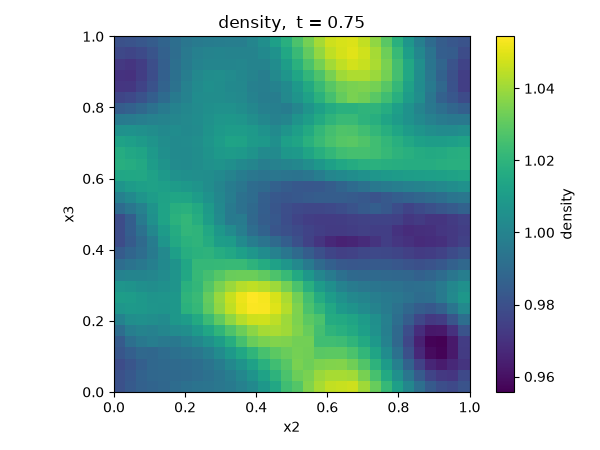

In [36]:
s.outputs["sl.x1.0.5"].at(t = 1)["density"]

You can also access the 2D numpy array for a single field directly as follows: 

In [37]:
s.outputs["sl.x1.0.5"].at(t = 1)["density"].data 

array([[0.98029469, 0.98372397, 0.98628538, ..., 0.97930098, 0.97751075,
        0.98117575],
       [0.98037316, 0.98296255, 0.98678777, ..., 0.97202078, 0.97121913,
        0.97756197],
       [0.97858773, 0.98176351, 0.98562045, ..., 0.96307817, 0.96702857,
        0.97058565],
       ...,
       [0.97210217, 0.97090056, 0.97384944, ..., 0.98775425, 0.98110862,
        0.97562056],
       [0.97712406, 0.97637842, 0.97793159, ..., 0.98530853, 0.98448582,
        0.97878414],
       [0.98011268, 0.98116633, 0.98271038, ..., 0.98467734, 0.98239831,
        0.98112342]], shape=(32, 32))

### Spectra

OutputFrame(idx=14, t=0.7, file=parthenon.spc_B.out6.00014.spc)
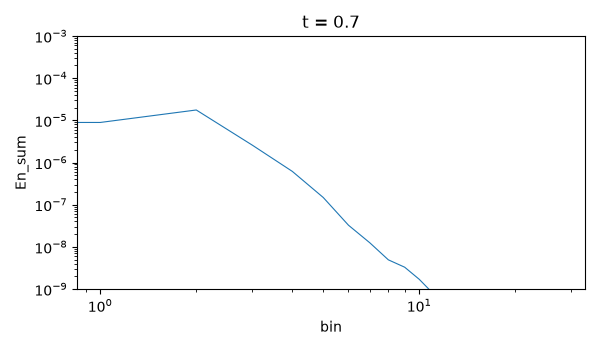

In [39]:
s.outputs["spc_B"].at(t = 1)

By default, this plots a log-log plot of the desired spectrum. To get more freedom in plotting, obtain the raw data as:

In [40]:
s.outputs["spc_B"].at(t = 1).data

,Bin,En_sum,K_sum,Count
0,0,1.000000e-04,0.000000,1
1,1,8.911337e-06,36.826969,26
2,2,1.760647e-05,158.394511,66
3,3,2.567502e-06,539.339257,158
4,4,6.162038e-07,1036.698092,234
5,5,1.483351e-07,2241.523755,410
6,6,3.260659e-08,3027.933580,470
7,7,1.247404e-08,5493.100623,738
8,8,4.925971e-09,7316.230086,866
9,9,3.296915e-09,11070.935705,1170
